# AI ANALYST LAB — Python Crash Course

![](../_img/ai_analyst_lab.png)

### From Zero to Python — a gentle companion for people who have never programmed
## Session 7: plotting — turning numbers into pictures

Feedback should be sent to [goran.milovanovic@datakolektiv.com](mailto:goran.milovanovic@datakolektiv.com).

You have loaded a real table, filtered it, and summarised it into neat numbers. Today you give those numbers a **face**. A good chart can tell in one glance what a table of numbers hides — *"survival fell steadily from first class to third"* is a sentence, but as a row of bars it is instant.

You'll draw a **histogram**, a couple of **bar charts** — including the very survival rates you computed last session — and meet **seaborn**, the tidy charting toolbox the main course uses.

Go slowly. You **cannot break anything**.

***
### What we will do today

- **Get set up** — a fresh file, data re-loaded (you know the drill by now).
- Understand **where your charts appear** — an important difference between IDLE, this notebook, and the main course's tools.
- Draw your first **histogram** of passenger ages.
- **Finish a chart properly** with a title and axis labels.
- Turn last session's **survival-by-class** numbers into a **bar chart**.
- Meet **seaborn** and draw one prettier chart.

Work in the **IDLE editor**, running with **Run → Run Module**. *(On a Mac, use the menu — F5 opens Dictation.)*

***
## 1. Getting set up

As always, a new file starts from scratch — so we re-load the data. Open **IDLE → File → New File**, **save it** into your **`AI_AnalystLAB` folder** (beside `Titanic_train.csv`, as ever) with the name **`plotting.py`**, and begin with the familiar two lines:

In [1]:
import pandas as pd

passengers = pd.read_csv("Titanic_train.csv")
print("Loaded:", passengers.shape)

Loaded: (891, 12)


`Loaded: (891, 12)` — the table is ready.

> **⚠️ Same reminder as always:** if you see **`FileNotFoundError`**, the CSV isn't in the same folder as `plotting.py`. Put them together and run again — or ask your instructor.

***
## 2. Before your first chart — *where will it appear?*

This is worth a full minute, because a chart behaves differently from the text you've printed so far, and knowing what to expect will save you a fright.

The **same charting code** shows its picture in **different places** depending on *where you run it*:

- **In IDLE (what you are using now):** the chart opens in its **own separate pop-up window**, floating in front of (or sometimes behind) IDLE. You look at it, then **close that window** to let your program carry on.
- **In this notebook (the HTML page you are reading):** the chart appears **right here on the page**, embedded just under the code that made it — because a notebook can display pictures inline. That is how you'll see every chart below.
- **In VS Code — the tool you'll use in the main AI Analyst LAB course:** everything is **integrated into one document**. Your code, your printed numbers, and your charts all sit together in the same notebook, with **no external windows at all**. It's the smoothest of the three; IDLE's pop-up window is simply the beginner tool's way of doing the same job.

So: **it is the exact same code every time** — only the *place the picture lands* changes. Don't be surprised when your IDLE chart opens in a window while the notebook shows it inline.

> **⚠️ An IDLE quirk to expect.** When you run charting code in IDLE, the pop-up window sometimes opens **behind** your other windows, and your program will seem to **freeze** until you deal with it. If that happens, look for the chart window (check your taskbar/Dock), and **close it** — your program then continues. This is normal, not a bug.

***
## 3. Your first chart — a histogram of ages

To draw charts we bring in another **add-on toolbox**: **matplotlib**, the workhorse behind almost every Python chart. By tradition its drawing part is nicknamed **`plt`**.

We'll start with a **histogram** — a chart that shows *how the values are spread out* by chopping the range into bands and drawing a bar for *how many* values fall in each band. It's the natural way to see the shape of the passengers' ages: are most young, old, spread evenly?

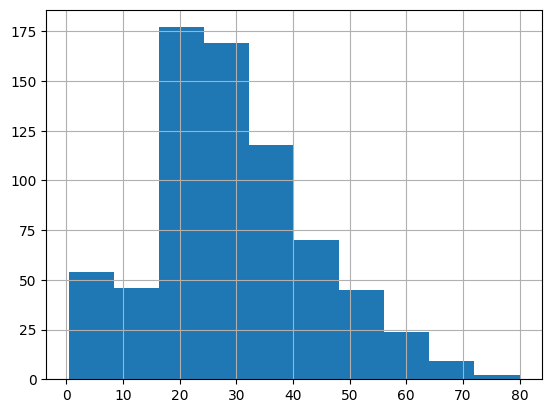

In [2]:
import matplotlib.pyplot as plt

passengers["Age"].hist()
plt.show()

Two short lines and you have a picture. Reading it: most passengers cluster in their **20s and 30s**, with a long thin tail toward the older ages and a small bump of children. The single call **`plt.show()`** is what actually *displays* the chart — in IDLE it opens the window; here in the notebook it draws inline, just above.

> *(Remember the 177 passengers with a missing age from Session 5? A histogram simply **leaves them out** — you can only draw a bar for an age that exists.)*

***
## 4. Finishing a chart — titles and labels

The chart above works, but it's rude: nothing tells a reader *what they're looking at*. A finished chart **always** has a **title** and **labels on both axes**. It's the one habit that separates a clear chart from a mystery — add it every single time.

Here's the same histogram, done properly:

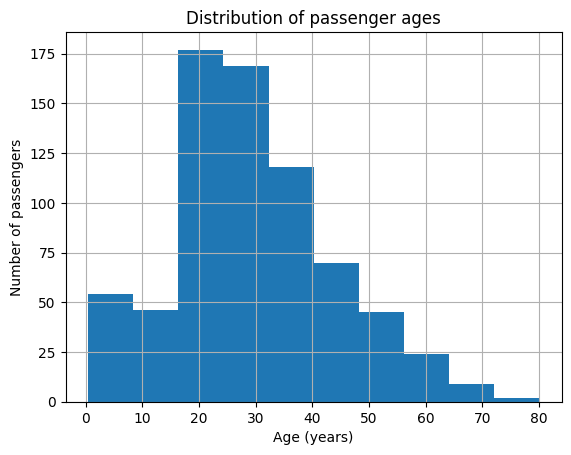

In [3]:
passengers["Age"].hist()

plt.title("Distribution of passenger ages")
plt.xlabel("Age (years)")
plt.ylabel("Number of passengers")
plt.show()

Now anyone can read it at a glance: **`plt.title(...)`** names the chart, **`plt.xlabel(...)`** and **`plt.ylabel(...)`** name the two axes. Notice the pattern: first you make the chart, then you add its title and labels, and **`plt.show()`** comes **last** — it's the "now display everything" button.

***
## 5. The payoff — your Session 6 numbers as a bar chart

Here's where it all comes together. Last session you computed the **survival rate for each passenger class** with `groupby`. A histogram was for one spread of numbers; to compare a handful of **groups**, the right picture is a **bar chart** — one bar per group.

We recompute that little summary, then ask pandas to plot it directly with **`.plot(kind="bar")`**:

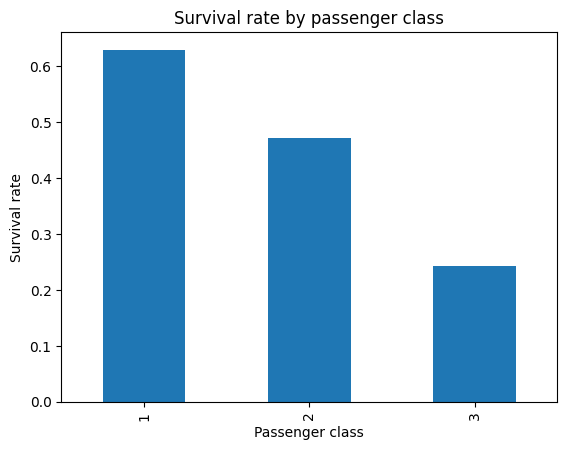

In [4]:
survival_by_class = passengers.groupby("Pclass")["Survived"].mean()

survival_by_class.plot(kind="bar")
plt.title("Survival rate by passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Survival rate")
plt.show()

Three bars, and the story you read as numbers last session is now **impossible to miss**: survival falls steeply from **1st class**, down through **2nd**, to **3rd**. The same facts you saw as `0.630, 0.473, 0.242` — but a reader *feels* the drop in the bars instantly. That is the whole reason we make charts.

> Notice **`.plot(kind="bar")`** hangs right off the summary — pandas can draw its own tables. The `kind="bar"` simply picks the *type* of chart; there is also `"line"`, `"hist"`, and more, for when you need them.

***
## 6. A prettier toolbox — seaborn

matplotlib draws everything, but its plain look takes effort to polish. **seaborn** is a second charting toolbox built *on top of* matplotlib — it makes good-looking charts with less typing, and it's the one the **main AI Analyst LAB course** reaches for. Its nickname is **`sns`**.

seaborn also has a lovely convenience: hand it the **whole table** and tell it which columns to use, and it will **do the grouping for you**. Watch it compute survival-by-sex and chart it in a single call:

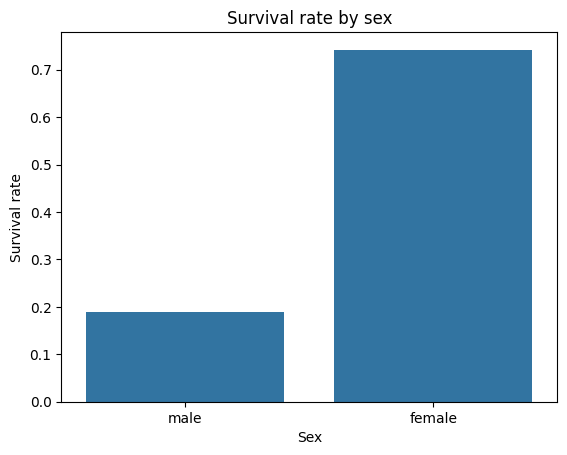

In [5]:
import seaborn as sns

sns.barplot(data=passengers, x="Sex", y="Survived", errorbar=None)
plt.title("Survival rate by sex")
plt.ylabel("Survival rate")
plt.show()

One call — `data=passengers` gives it the table, `x="Sex"` splits into groups, `y="Survived"` is what to average — and seaborn drew the same **women ≈ 0.74 vs men ≈ 0.19** gap you found by hand last session, but tidier and with almost no code. *(The `errorbar=None` just switches off an extra statistical whisker seaborn would otherwise add — we don't need it yet.)*

`plt.title` and `plt.ylabel` still work here, because seaborn draws *through* matplotlib — the two toolboxes cooperate.

***
## What you can now do — and what's next

Today your numbers grew a face. You learned to:

- draw a **histogram** to see the shape of a column (`.hist()`);
- **finish** any chart with a **title** and **axis labels**;
- turn a `groupby` summary into a **bar chart** (`.plot(kind="bar")`);
- draw a quick, tidy chart with **seaborn** (`sns.barplot(...)`);
- and always end with **`plt.show()`** — and know *where* the picture will appear.

You now have the full everyday loop of a data analyst: **load → filter → group → chart.** Everything in the main AI Analyst LAB course is, at heart, richer versions of these same four moves — done in VS Code, where code, numbers, and charts live together in one notebook.

Next, **Session 8** takes a step back to a bigger idea: **objects**. You've been using `.something()` on tables, columns, and charts all along — next you'll finally see what those "things" really are, and why almost everything in Python is one. It's the last idea you need before the grand finale, **Session 9: pydantic**.

> **⚠️ Quick reminders:**
> - **`plt.show()`** is what displays a chart — in IDLE it's a **pop-up window** (close it to continue); here it's **inline**.
> - Every chart deserves a **title** and **axis labels** — add them every time.
> - `matplotlib` (nicknamed `plt`) and `seaborn` (`sns`) are **add-ons**, like pandas — imported, not built in.

See you in Session 8.

<hr>

![](../_img/DK_Logo_White_150.png)

DataKolektiv, 2026.

[hello@datakolektiv.com](mailto:hello@datakolektiv.com)

<font size=1>License: [GPLv3](../LICENSE). This Notebook is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version. This Notebook is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.</font>